# 1. Mapping Utilities (1910 subset)

This notebook builds reliable mappings between:

- `1910_embeddings.npy` (CLIP vectors)
- `1910_embeddings.txt` (one filename/ID per row)
- `1910_photos/` (actual image files)

Using the interactive module, users can:

- look up an image by index
- look up an index by filename
- retrieve the corresponding embedding vector
- load/display the corresponding image


## Setup


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display, clear_output

import random

# running in current directory (sample_photos)
BASE_DIR = Path(".")

PHOTOS_DIR = BASE_DIR / "1910_photos"
EMB_NPY = BASE_DIR / "1910_embeddings.npy"
EMB_TXT = BASE_DIR / "1910_embeddings.txt"

print("Working directory:", BASE_DIR.resolve())
print("Found photos dir:", PHOTOS_DIR.exists(), PHOTOS_DIR)
print("Found embeddings:", EMB_NPY.exists(), EMB_NPY)
print("Found filenames:", EMB_TXT.exists(), EMB_TXT)


Working directory: /Users/hannahsun/Desktop/ind_study/viral-images/scripts/sample-photos
Found photos dir: True 1910_photos
Found embeddings: True 1910_embeddings.npy
Found filenames: True 1910_embeddings.txt


## Load embeddings + filename list

`1910_embeddings.txt` contains one filename/ID per row, aligned with rows in `1910_embeddings.npy`.


In [2]:
lines = EMB_TXT.read_text(encoding="utf-8").splitlines()
filenames_1910 = [ln.strip() for ln in lines if ln.strip()]

embs = np.load(EMB_NPY)
if embs.ndim != 2:
    raise ValueError(f"Expected 2D embedding matrix, got shape={embs.shape}")
embeddings_1910 = embs

print("filenames:", len(filenames_1910))
print("embeddings:", embeddings_1910.shape)

if len(filenames_1910) != embeddings_1910.shape[0]:
    raise ValueError(
        "Row mismatch: filenames and embedding rows must match. "
        f"Got {len(filenames_1910)} filenames vs {embeddings_1910.shape[0]} embedding rows."
    )

print("Alignment check passed")

filenames: 72062
embeddings: (72062, 512)
Alignment check passed


## Build lookup map

1. `idx_to_name` maps index to filename
2. `name_to_idx` maps filename to index


In [3]:
idx_to_name: List[str] = filenames_1910
name_to_idx: Dict[str, int] = {}

# duplicate check in filename
dupes = []
for i, name in enumerate(idx_to_name):
    if name in name_to_idx:
        dupes.append(name)
    else:
        name_to_idx[name] = i

print("unique names:", len(name_to_idx))
if dupes:
    print("Duplicate filenames detected (showing up to 10):", dupes[:10])
else:
    print("No duplicates in filename list")


unique names: 72062
No duplicates in filename list


## Resolve filenames to image paths

Map entries from `1910_embeddings.txt` to actual .jpg files in `1910_photos/`


In [4]:
matched = 0
unmatched = 0
unmatched_list = []

for name in filenames_1910:
    stem = Path(name).stem
    p = PHOTOS_DIR / f"{stem}.jpg"
    if not p.exists():
        p = None
    
    if p is not None:
        matched += 1
    else:
        unmatched += 1
        unmatched_list.append(name)

print("Total embedding IDs:", len(filenames_1910))
print("Matched:", matched)
print("Unmatched:", unmatched)
print(f"Match rate: {matched/len(filenames_1910)*100:.2f}%")
print(f"Unmatched list:")
for i in unmatched_list:
    print(i)


Total embedding IDs: 72062
Matched: 72052
Unmatched: 10
Match rate: 99.99%
Unmatched list:
nbu_ancientbison_ver01_data_2018270203_00279527422_1911042001_0470_000_0_99
hihouml_ecru_ver01_data_sn82015415_00237285967_1911122701_1402_007_0_91
curiv_betteravia_ver02_data_sn85066387_00175035953_1911032901_0667_017_0_95
whi_lethifold_ver01_data_sn86086067_00414214745_1911062901_0106_005_0_91
in_kautsky_ver01_data_sn86058226_00271744894_1911031501_0602_008_0_96
nn_dansereau_ver02_data_sn83030272_00206533547_1911041601_0856_004_0_97
tu_ernie_ver01_data_sn86064259_00296020588_1911101301_0328_001_0_98
mdu_jalapeno_ver02_data_sn83045081_00296025975_1911112601_0804_004_0_98
in_chucktaylor_ver02_data_sn86058242_00271745916_1911121501_0107_008_0_90
vi_mcqueen_ver01_data_10021978_00271764698_1911081601_0382_005_0_93


In [5]:
with open("mapping_matches.txt", "w", encoding="utf-8") as f:
    for name in filenames_1910:
        stem = Path(name).stem
        p = PHOTOS_DIR / f"{stem}.jpg"

        if p.exists():
            f.write(f"MATCH: {name} -> {p}\n")
        else:
            f.write(f"NO MATCH: {name}\n")

print("Wrote full mapping log to mapping_matches.txt")

Wrote full mapping log to mapping_matches.txt


## Helper functions for interactive visualizer

In [6]:
def get_name(i: int) -> str:
    return idx_to_name[i]

def load_image_by_index(i: int) -> Image.Image:
    name = get_name(i)
    stem = Path(name).stem
    p = PHOTOS_DIR / f"{stem}.jpg"

    if not p.exists():
        raise FileNotFoundError(f"Could not find image file: {p}")

    return Image.open(p).convert("RGB")

def show_image(i: int, figsize=(5,5)):
    img = load_image_by_index(i)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"idx={i} | {get_name(i)}")
    plt.show()


## Sanity checks

Embedding dimension: 512


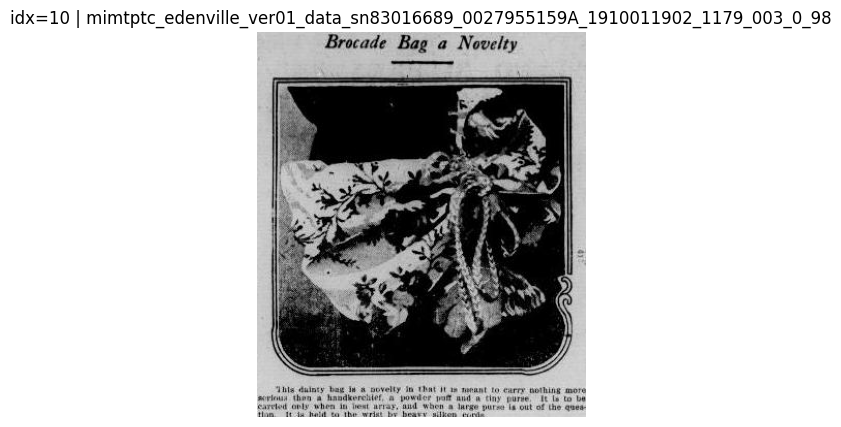

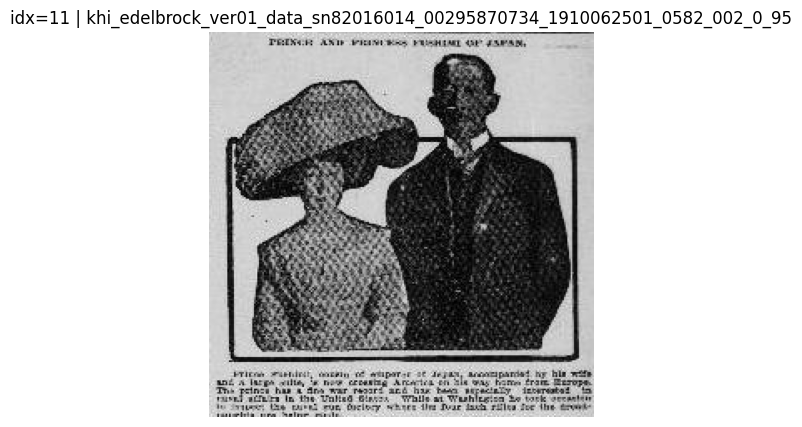

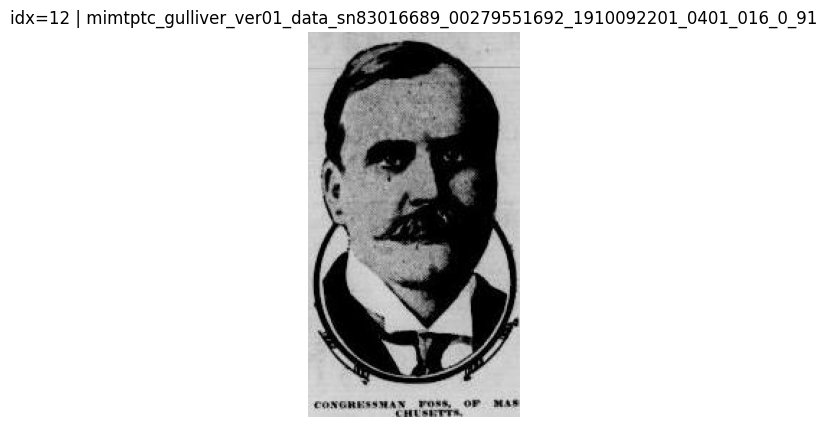

In [7]:
print("Embedding dimension:", embeddings_1910.shape[1])

shown = 0
i = 0

while shown < 3 and i < len(filenames_1910):
    try:
        show_image(i)
        shown += 1
    except FileNotFoundError:
        pass # expect first image to be idx=10 as the first 10 are not matched
    i += 1

if shown < 3:
    print(f"Only found {shown} resolvable images.")


In [8]:
# set sample_n to 200: randomly choose 200 indices and count how many resolve to real images
idxs = random.sample(range(len(idx_to_name)), min(200, len(idx_to_name)))
ok = 0

for i in idxs:
    name = idx_to_name[i]
    stem = Path(name).stem
    p = PHOTOS_DIR / f"{stem}.jpg"
    if p.exists():
        ok += 1

rate = ok / len(idxs)
print(f"Resolved ~{rate*100:.1f}% of sampled images")


Resolved ~100.0% of sampled images


## Interactive Lookup Panel
If widgets don't render, run: pip install ipywidgets && jupyter nbextension enable --py widgetsnbextension

In [ ]:
if "PHOTOS_DIR" not in globals():
    PHOTOS_DIR = Path("1910_photos")

print("Using PHOTOS_DIR:", PHOTOS_DIR)

## User Interface: input fields, buttons, and output area
max_idx = len(idx_to_name) - 1

idx_input = widgets.BoundedIntText(
    value=0, min=0, max=max_idx, step=1, description="Index:",
    layout=widgets.Layout(width="250px")
)
idx_slider = widgets.IntSlider(
    value=0, min=0, max=max_idx, step=1, description="",
    continuous_update=False, layout=widgets.Layout(width="500px")
)
name_input = widgets.Text(
    value="", placeholder="Paste filename/ID from 1910_embeddings.txt",
    description="Filename:", layout=widgets.Layout(width="760px")
)

btn_idx_to_name = widgets.Button(description="Index -> Filename")
btn_name_to_idx = widgets.Button(description="Filename -> Index")
btn_show_embed  = widgets.Button(description="Show embedding preview", button_style="info")
btn_show_image  = widgets.Button(description="Show image", button_style="success")

out = widgets.Output()

idx_input.observe(lambda ch: setattr(idx_slider, "value", ch["new"]) if ch["name"] == "value" else None, names="value")
idx_slider.observe(lambda ch: setattr(idx_input, "value", ch["new"]) if ch["name"] == "value" else None, names="value")


# Event handlers
def on_idx_to_name(_):
    with out:
        clear_output()
        i = idx_input.value
        try:
            if i < 0 or i >= len(idx_to_name):
                raise IndexError(f"Index out of range: {i}")
            name = idx_to_name[i]
            name_input.value = name

            stem = Path(name).stem
            p = PHOTOS_DIR / f"{stem}.jpg"
            print(f"Index {i} -> filename:\n  {name}")
            print(f"Resolved path:\n  {p if p.exists() else 'None (NO MATCH)'}")
        except Exception as e:
            print("Error:", e)

def on_name_to_idx(_):
    with out:
        clear_output()
        try:
            name = name_input.value.strip()
            if name not in name_to_idx:
                raise KeyError(f"Filename not found in 1910_embeddings.txt: {name}")
            i = name_to_idx[name]
            idx_input.value = i  

            stem = Path(name).stem
            p = PHOTOS_DIR / f"{stem}.jpg"
            print(f"Filename -> index:\n  {name} -> {i}")
            print(f"Resolved path:\n  {p if p.exists() else 'None (NO MATCH)'}")
        except Exception as e:
            print("Error:", e)

def on_show_embed(_):
    with out:
        clear_output()
        i = idx_input.value
        try:
            if i < 0 or i >= len(idx_to_name):
                raise IndexError(f"Index out of range: {i}")
            name = idx_to_name[i]
            v = embeddings_1910[i]
            head = 8
            print(f"Embedding preview for idx={i}")
            print(f"Filename: {name}")
            print(f"Dimension: {int(v.shape[0])}")
            print(f"L2 norm: {float(np.linalg.norm(v)):.4f}") # vector length
            print(f"First values: {[float(x) for x in v[:head]]}")
        except Exception as e:
            print("Error:", e)

def on_show_image(_):
    with out:
        clear_output()
        i = idx_input.value
        try:
            if i < 0 or i >= len(idx_to_name):
                raise IndexError(f"Index out of range: {i}")
            name = idx_to_name[i]
            stem = Path(name).stem
            p = PHOTOS_DIR / f"{stem}.jpg"
            if not p.exists():
                raise FileNotFoundError(f"Could not find image file: {p}")

            img = Image.open(p).convert("RGB")
            plt.figure(figsize=(5, 5))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"idx={i} | {name}")
            plt.show()
        except Exception as e:
            print("Error:", e)

btn_idx_to_name.on_click(on_idx_to_name)
btn_name_to_idx.on_click(on_name_to_idx)
btn_show_embed.on_click(on_show_embed)
btn_show_image.on_click(on_show_image)

controls = widgets.VBox([
    widgets.HBox([idx_input, btn_idx_to_name]),
    idx_slider,
    widgets.HBox([name_input]),
    widgets.HBox([btn_name_to_idx, btn_show_embed, btn_show_image]),
])

display(controls, out)

Using PHOTOS_DIR: 1910_photos


Output()